# 2주차 실습: Confusion Matrix 시각화

## 학습 목표
- AI 분류 모델의 성능을 평가하는 지표(혼동행렬, 민감도, 특이도)를 이해할 수 있다
- 패혈증 예측 AI 모델의 결과를 혼동행렬(Heatmap)으로 시각화할 수 있다
- 민감도(Sensitivity)와 특이도(Specificity)를 직접 계산할 수 있다

---

## AI 모델도 '틀릴 수 있다'

병원에서 '패혈증 위험 환자를 예측하는 AI'가 도입된다고 가정했을 때,
AI가 내린 판정과 실제 결과는 4가지 경우로 나뉨

| | 예측 Negative | 예측 Positive |
|---|---|---|
| **실제 환자(패혈증 O)** |  **TP** (진양성) |  **FN** (위음성 — 가장 위험한 케이스) |
| **실제 정상(패혈증 X)** |  **FP** (위양성) |  **TN** (진음성) |


> **FN(False Negative)이 특히 위험한 이유**는 실제 패혈증 환자를 '정상'으로 놓치는 경우이기 때문

### 임상에서 중요한 두 지표
- **민감도(Sensitivity/Recall):** `TP / (TP + FN)` — 실제 환자를 찾아내는 능력
- **특이도(Specificity):** `TN / (TN + FP)` — 정상인을 정상으로 판별하는 능력

> 민감도는 '그물코의 촘촘함'. 민감도가 높을수록 더 많은 환자를 잡아내지만, 정상인도 걸릴 수 있음

In [3]:
!pip install seaborn scikit-learn japanize_matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 11.2 MB/s  0:00:00 eta 0:00:01
  Preparing metadata (setup.py) ... done
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 11.4 MB/s  0:00:00 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  DEPRECATION: Building 'japanize_matplotlib' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'japanize_matplotlib'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120306 sha25

In [ ]:
# 필요한 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print('라이브러리 로드 완료!')

라이브러리 로드 완료!


## 패혈증 예측 AI 모델 결과 데이터 생성

- 총 200명의 환자 데이터
- 실제 패혈증 환자: 100명 / 실제 정상: 100명
- AI 예측 결과가 저장된 가상 데이터

In [5]:
# 가상의 패혈증 예측 AI 결과 생성
# y_true: 실제 진단 (1=패혈증, 0=정상)
# y_pred: AI 예측 (1=패혈증 예측, 0=정상 예측)

# TP=85, FN=15, FP=10, TN=90
y_true = [1]*100 + [0]*100  # 실제: 앞 100명 패혈증, 뒤 100명 정상
y_pred = [1]*85 + [0]*15 + [1]*10 + [0]*90  # AI 예측

print(f'전체 환자 수: {len(y_true)}명')
print(f'실제 패혈증 환자: {sum(y_true)}명')
print(f'AI가 패혈증으로 예측한 환자: {sum(y_pred)}명')

전체 환자 수: 200명
실제 패혈증 환자: 100명
AI가 패혈증으로 예측한 환자: 95명


## 혼동행렬(Confusion Matrix) 계산

In [6]:
# 혼동행렬 계산
cm = confusion_matrix(y_true, y_pred)
print('혼동행렬:')
print(cm)
print()
print(f'TN (진음성): {cm[0][0]}')
print(f'FP (위양성): {cm[0][1]}')
print(f'FN (위음성): {cm[1][0]}')
print(f'TP (진양성): {cm[1][1]}')

혼동행렬:
[[90 10]
 [15 85]]

TN (진음성): 90
FP (위양성): 10
FN (위음성): 15
TP (진양성): 85


## 혼동행렬 히트맵 시각화

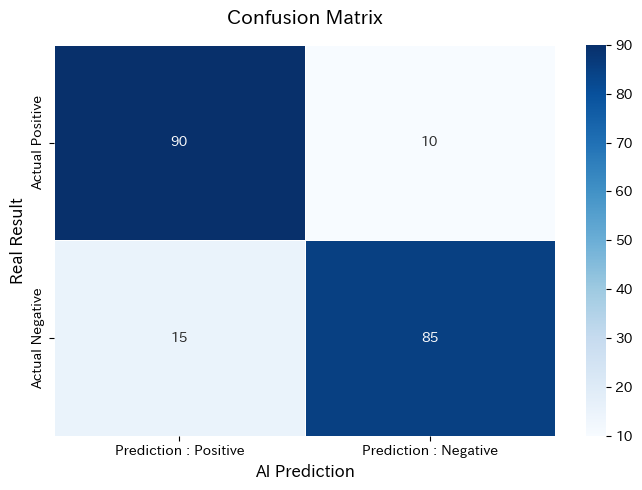

초록 대각선: 올바른 예측 (TP, TN)
빨간 비대각: 잘못된 예측 (FP, FN)


In [9]:
# 혼동행렬을 히트맵으로 시각화
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Prediction : Positive', 'Prediction : Negative'],
    yticklabels=['Actual Positive', 'Actual Negative'],
    linewidths=0.5,
    ax=ax
)

ax.set_title('Confusion Matrix', fontsize=14, pad=15)
ax.set_ylabel('Real Result', fontsize=12)
ax.set_xlabel('AI Prediction', fontsize=12)
plt.tight_layout()
plt.show()

print('초록 대각선: 올바른 예측 (TP, TN)')
print('빨간 비대각: 잘못된 예측 (FP, FN)')

## 민감도(Sensitivity)와 특이도(Specificity) 직접 계산

In [11]:
# 혼동행렬에서 각 값 추출
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

# 민감도(Sensitivity/Recall) = TP / (TP + FN)
# 실제 패혈증 환자 중 AI가 올바르게 패혈증으로 예측한 비율
sensitivity = TP / (TP + FN)

# 특이도(Specificity) = TN / (TN + FP)
# 실제 정상 환자 중 AI가 올바르게 정상으로 예측한 비율
specificity = TN / (TN + FP)

# 정밀도(Precision) = TP / (TP + FP)
precision = TP / (TP + FP)

# 정확도(Accuracy) = (TP + TN) / 전체
accuracy = (TP + TN) / len(y_true)

print('=== AI 모델 성능 평가 결과 ===')
print(f'민감도 (Sensitivity/Recall): {sensitivity:.2f}')
print(f'특이도 (Specificity):        {specificity:.2f}')
print(f'정밀도 (Precision):          {precision:.2f}')
print(f'정확도 (Accuracy):           {accuracy:.2f}')
print()
print(f'해석: 이 AI는 실제 패혈증 환자 100명 중 {TP}명을 정확히 찾아냄')
print(f'     {FN}명의 패혈증 환자를 놓침 (위음성)')

=== AI 모델 성능 평가 결과 ===
민감도 (Sensitivity/Recall): 0.85
특이도 (Specificity):        0.90
정밀도 (Precision):          0.89
정확도 (Accuracy):           0.88

해석: 이 AI는 실제 패혈증 환자 100명 중 85명을 정확히 찾아냄
     15명의 패혈증 환자를 놓침 (위음성)


## 추가: sklearn 자동 분류 리포트

In [12]:
# sklearn이 자동으로 계산해주는 분류 리포트
print('=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=['정상', '패혈증']))

=== Classification Report ===
              precision    recall  f1-score   support

          정상       0.86      0.90      0.88       100
         패혈증       0.89      0.85      0.87       100

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.87       200
weighted avg       0.88      0.88      0.87       200



---

## Canvas 퀴즈 안내

아래 코드 셀을 실행하여 나온 **숫자**를 Canvas 퀴즈의 정답으로 제출

**문제:** 코드 실행 결과, 이 AI 모델이 패혈증 환자를 정확히 찾아낸 비율인 **민감도(Recall)**는 소수점 둘째 자리까지 얼마인가?

In [ ]:
# [실습] 아래 코드를 실행하여 나온 결과를 Canvas 퀴즈의 정답으로 제출
canvas_answer = round(sensitivity, 2)
print(f'Answer: {canvas_answer}')